In [17]:
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc
from scipy.stats import skew, kurtosis
from tensorflow.keras.utils import Sequence
import tensorflow as tf
tf.keras.backend.clear_session()

In [20]:
# Create an ImageDataGenerator for unseen data
unseen_datagen = ImageDataGenerator(rescale=1.0/255)
image_size = (256, 256)
batch_size = 8
# Create a generator for unseen data
unseen_generator = unseen_datagen.flow_from_directory(
    "/home/umar_ali/seml_2025/data/unseen_data",  # Replace with the path to unseen data
    target_size=(image_size[0], image_size[1]),  # Resize images to the target size
    batch_size=batch_size,
    class_mode=None,  # No labels for testing
    shuffle=False  # Don't shuffle to preserve the order
)

# Helper function to extract statistical features for unseen data
def extract_statistical_features(batch_images):
    features = []
    for img in batch_images:
        img_flat = img.flatten()  # Flatten the image
        mean = np.mean(img_flat)
        std = np.std(img_flat)
        skewness = skew(img_flat) # Skewness of distribution as a measure of data symmetry
        kurt = kurtosis(img_flat) # Kurtosis is measure of tailedness of data
        features.append([mean, std, skewness, kurt])
    return np.array(features)

# Create a feature generator for unseen data
class FeatureExtractionDataGenerator(Sequence):
    def __init__(self, image_generator):
        self.image_generator = image_generator

    def __len__(self):
        return len(self.image_generator)

    def __getitem__(self, index):
        batch_images = self.image_generator[index]  # No labels for unseen data
        features = extract_statistical_features(batch_images)
        return {"image_input": batch_images, "stat_input": features}

# Wrap the unseen generator
unseen_feature_generator = FeatureExtractionDataGenerator(unseen_generator)

# Example usage with unseen data
sample_batch = unseen_feature_generator[0]
image_batch = sample_batch["image_input"]  # Access image data
feature_batch = sample_batch["stat_input"]  # Access statistical features

print("Unseen image batch shape:", image_batch.shape)  # Shape of the images
print("Unseen feature batch shape:", feature_batch.shape)  # Shape of the features



Found 108 images belonging to 1 classes.
Unseen image batch shape: (8, 256, 256, 3)
Unseen feature batch shape: (8, 4)


In [23]:
# Load the trained model
from tensorflow.keras.models import load_model
cnn = load_model('CNN_with_feature_layers.h5')

In [24]:
# Make predictions on unseen data
predictions = cnn.predict(unseen_feature_generator)

# Convert predictions to binary class labels
predicted_classes = (predictions > 0.5).astype(int)

# Print predictions and predicted classes
print("Predictions:", predictions)
print("Predicted Classes:", predicted_classes)

/home/umar_ali/SEML/virtual_folder/venv/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
/home/umar_ali/SEML/virtual_folder/venv/lib/python3.12/site-packages/keras/src/models/functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['image_input', 'stat_input']. Received: the structure of inputs={'image_input': '*', 'stat_input': '*'}
  warnings.warn(


14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step
Predictions: [[1.4726967e-01]
 [9.8753732e-01]
 [1.4486871e-02]
 [5.5806111e-03]
 [7.0075101e-01]
 [1.8776997e-03]
 [6.0015277e-04]
 [1.4757819e-01]
 [1.0277615e-01]
 [1.6821705e-02]
 [9.5857322e-01]
 [9.7084818e-03]
 [9.6943807e-03]
 [2.7340723e-02]
 [1.4032692e-03]
 [4.4082908e-04]
 [2.0301209e-01]
 [5.0291285e-04]
 [1.4421014e-01]
 [8.4436774e-01]
 [3.1611636e-02]
 [1.3309551e-02]
 [2.4745849e-01]
 [2.0507726e-04]
 [1.6719830e-01]
 [8.0947645e-02]
 [1.7963603e-01]
 [7.8679658e-03]
 [9.8740762e-01]
 [1.3997207e-02]
 [7.7697276e-03]
 [2.7834085e-01]
 [9.8890680e-01]
 [1.5763573e-02]
 [7.4308133e-01]
 [4.6625236e-01]
 [7.5178752e-03]
 [4.3020573e-01]
 [7.4166211e-04]
 [3.9223349e-05]
 [1.2512703e-01]
 [3.9153835e-01]
 [9.3945246e-03]
 [9.7424322e-01]
 [1.0330157e-02]
 [1.2022786e-02]
 [8.3199406e-01]
 [6.7558051e-03]
 [2.2890617e-04]
 [5.5539054e-01]
 [8.7861854e-01]
 [6.9802222e-03]
 [4.8750320e-01]
 [1.1218577e-02]
 [1.0377355e-02]
 [9.7605389e

Accuracy: 0.77
Recall: 1.00


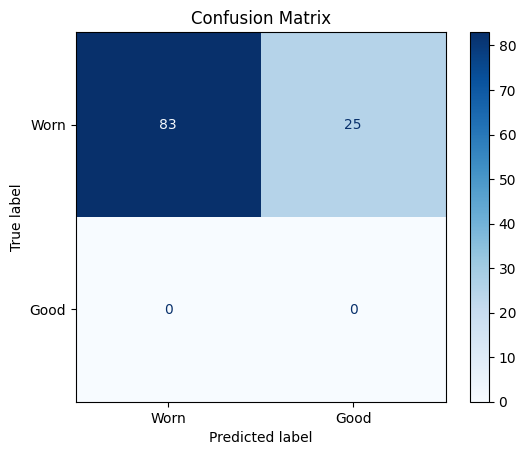

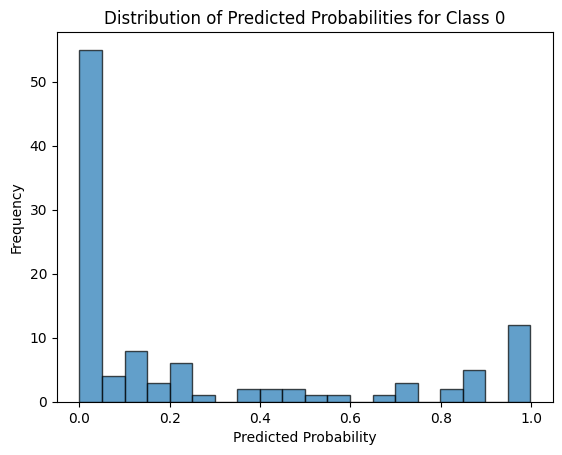

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.77      0.87       108
         1.0       0.00      0.00      0.00         0

    accuracy                           0.77       108
   macro avg       0.50      0.38      0.43       108
weighted avg       1.00      0.77      0.87       108



/home/umar_ali/SEML/virtual_folder/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/umar_ali/SEML/virtual_folder/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/umar_ali/SEML/virtual_folder/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, classification_report
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# True labels for unseen data (all belong to class 0)
true_labels = np.zeros(len(unseen_generator.filenames))  # All 0s

# Compute metrics
accuracy = accuracy_score(true_labels, predicted_classes)
precision = precision_score(true_labels, predicted_classes, zero_division=1)
recall = recall_score(true_labels, predicted_classes, zero_division=1)
f1 = f1_score(true_labels, predicted_classes, zero_division=1)

# Print metrics
print(f"Accuracy: {accuracy:.2f}")
print(f"Recall: {recall:.2f}")

# Confusion Matrix
cm = confusion_matrix(true_labels, predicted_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Worn', 'Good'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

# Distribution of Predicted Probabilities
plt.hist(predictions, bins=20, edgecolor='k', alpha=0.7)
plt.title("Distribution of Predicted Probabilities for Class 0")
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.show()

# Print classification report
print("Classification Report:")
print(classification_report(true_labels, predicted_classes))

